In [1]:
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [ ]:
!pip install torch

In [1]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
import torch

In [2]:
from google.cloud import storage
from google.cloud import bigquery

import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow

from google.cloud import bigquery


#client = storage.Client()
#bucket = client.bucket('cdow')


# Initialize the BigQuery client
client = bigquery.Client()

# Define the table reference, which was used in the previous cell
#table_ref = "expanded-nebula-754.sandbox_crdow.leads_training_set_text_category_all"
#leads_training_set_text_category_IID
#table_ref = "expanded-nebula-754.sandbox_crdow.leads_training_set_text_category_IID"
table_ref = "expanded-nebula-754.sandbox_crdow.leads_training_set_test_train_category_IID"
# Use the BigQuery client to download the table directly into a DataFrame.
# This is more reliable than exporting to GCS and then reading from GCS.
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.


In [3]:
pd.set_option('display.max_rows', None)
#["a_campaign_name"]
#["a_leads_recent"]a_campaign_name_tok	a_leads_recent_tok
# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
display(df.iloc[0:10])
display(df.dtypes)
display(df.shape)

Individual_id a_search_terms                    a_source_campaigns  \
0  888100004601597             []                                    []   
1     100002904791             []                                    []   
2     100001264207             []                                    []   
3  888100001582232             []                                    []   
4  888100004786105    [sic fiber]                          [(referral)]   
5     100002309232             []                                    []   
6     100002244335   [tamsulosin]  [biology_us_shopping_(bing ebizpfs)]   
7     100002804761   [e1014-25ku]                           [(not set)]   
8  888100003015168             []                                    []   
9     100000966872             []                                    []   

            a_product_interest             a_leads_recent a_nielsen_id_lvl_1  \
0                           []                         []                 []   
1  [LabWater Service Contract]                 [Referral]         [Academia]   
2                           []                         []                 []   
3       [LabWater Consumables]  [Telemarketing/Telesales]                 []   
4   [Other (Specify in Notes)]        [Technical Service]         [Academia]   
5   [Other (Specify in Notes)]            [Sales Support]                 []   
6  [LabWater Service Contract]                 [Referral]   [Pharma/Biotech]   
7                           []                         []         [Academia]   
8                           []                         []                 []   
9                           []                         []   [Pharma/Biotech]   

       a_nielsen_id_lvl_2  page_views  days_since_last_order  \
0                      []           0                    NaN   
1  [Universities/Schools]           0                  471.0   
2                      []           0                    NaN   
3                      []           0                    NaN   
4  [Universities/Schools]          21                  475.0   
5                      []           0                    NaN   
6        [Pharmaceutical]          31                  475.0   
7  [Universities/Schools]          50                  797.0   
8                      []           0                    NaN   
9        [Pharmaceutical]           0                 1043.0   

   days_since_last_visit  avg_session_duration a_url  \
0                    NaN                   NaN    []   
1                    NaN                   NaN    []   
2                    NaN                   NaN    []   
3                    NaN                   NaN    []   
4                  426.0                 515.0    []   
5                    NaN                   NaN    []   
6                  329.0                 325.0    []   
7                  894.0                 143.0    []   
8                    NaN                   NaN    []   
9                    NaN                   NaN    []   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

,0
Individual_id,Int64
a_search_terms,object
a_source_campaigns,object
a_product_interest,object
a_leads_recent,object
a_nielsen_id_lvl_1,object
a_nielsen_id_lvl_2,object
page_views,Int64
days_since_last_order,float64
days_since_last_visit,float64


(245003, 15)

In [4]:
def preprocess_url(url):
    if pd.isna(url) or url.strip() == "":
        return "__MISSING__"

    # Remove protocol
    url = re.sub(r'^https?:\/\/', ' ', url)

    # Replace separators with space
    url = re.sub(r'[\/\.\?\=\&\%\:\;\_\-]', ' ', url)

    # Remove common file extensions and tokens m Body content 14382 id 9a63 4b7a 88f4 activityid 245b 42f0 bfff medium email
    url = re.sub(r'\b(html|php|aspx|www|RedirectTo|jsp|json|xml|utm|medium|source|sfmc|Banner|Imagecontent|listid|subscriberid|JobSubscriberBatchID|Body|Full_string|Logo Image URL|txt|@Logo Image URL)\b', ' ', url, flags=re.IGNORECASE)

    # Remove long alphanumeric strings (≥8 chars) that contain digits
    url = re.sub(r'\b(?=\w{8,})(?=\w*\d)\w+\b', ' ', url)
    # Remove exactly 2-digit numbers
    url = re.sub(r'\b\d{2}\b', ' ', url)

    # Remove exactly 3-character alphanumeric strings with at least one digit and one letter
    url = re.sub(r'\b(?=[a-zA-Z0-9]{3}$)(?=[a-zA-Z]*\d)(?=\d*[a-zA-Z])[a-zA-Z0-9]{4}\b', ' ', url)
    url = re.sub(r'\b(?=[a-zA-Z0-9]{3}$)(?=[a-zA-Z]*\d)(?=\d*[a-zA-Z])[a-zA-Z0-9]{3}\b', ' ', url)
    url = re.sub(r'\b(?=[a-zA-Z0-9]{3}$)(?=[a-zA-Z]*\d)(?=\d*[a-zA-Z])[a-zA-Z0-9]{2}\b', ' ', url)

    # Collapse multiple spaces
    url = re.sub(r'\s+', ' ', url).strip()

    return url

def process_url_list(url_list):
    # Handle NaN or None
    if url_list is None or isinstance(url_list, float) and pd.isna(url_list):
        return ["__MISSING__"]

    # Convert numpy array to list if needed
    if isinstance(url_list, np.ndarray):
        url_list = url_list.tolist()

    # Handle empty list
    if not url_list:
        return ["__MISSING__"]

    # Process each string
    return [preprocess_url(url) if isinstance(url, str) and url.strip() != "" else "__MISSING__" for url in url_list]

df['processed_url'] = df['a_url'].apply(process_url_list)

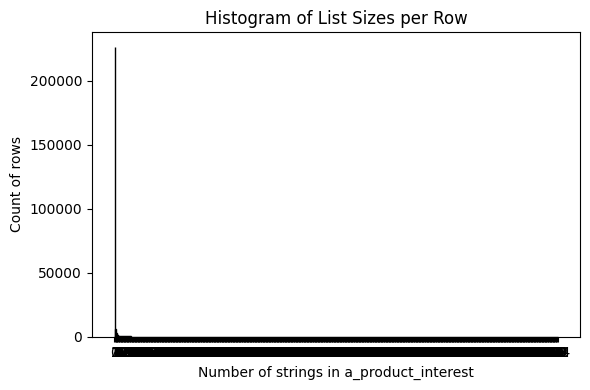

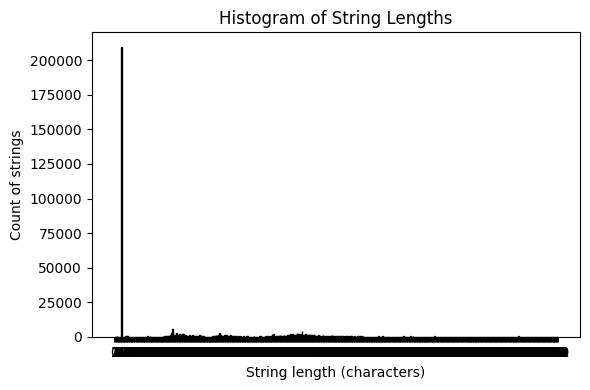

Number of unique strings: 25222

Top 20 most frequent strings:
processed_url
__MISSING__                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           209786
view e sigmaaldrich com j m ex2 MemberID ls ex2 listsubid l ex2 s ex2 jb ex2 ju ex2 joburlid                                                                                                                                                                                                                                                                                                                  

/tmp/ipykernel_27727/4217114104.py:115: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


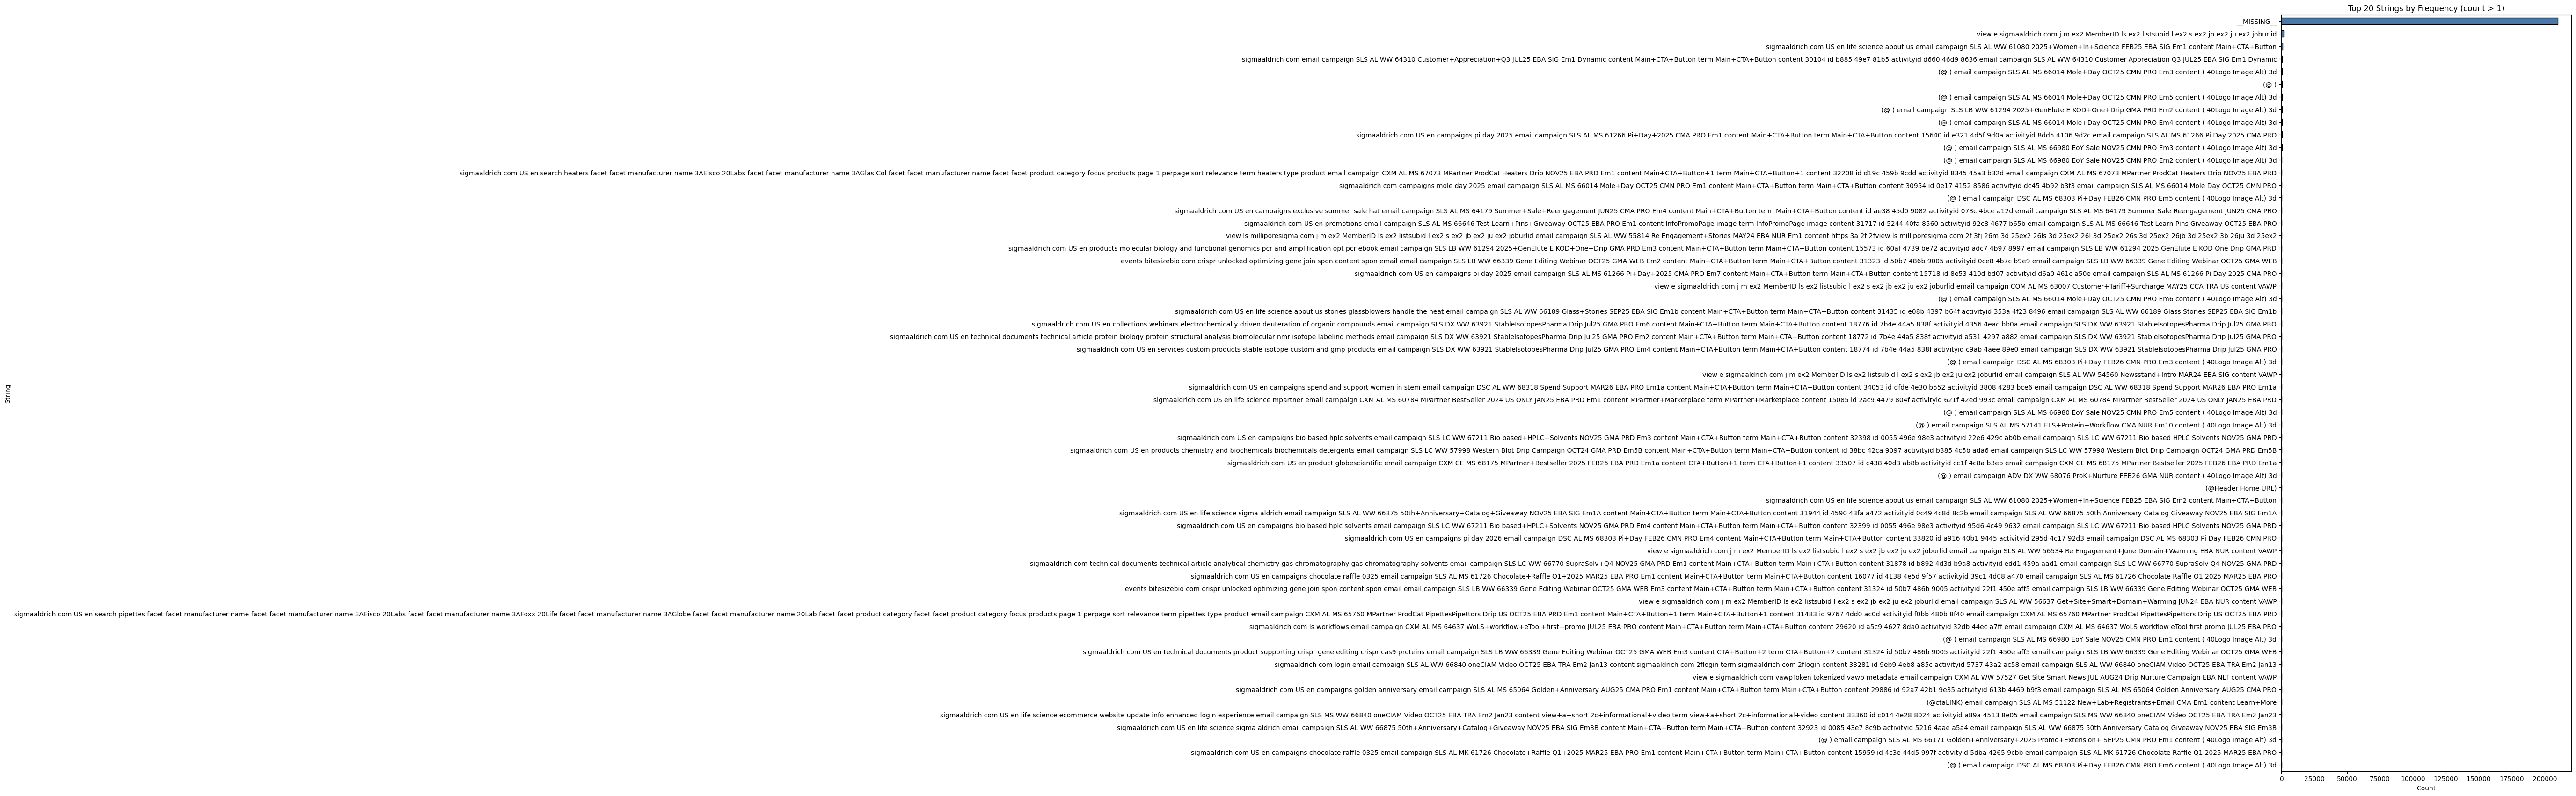

In [5]:
#self.product = pd.Categorical(df['a_product_interest']).codes
#self.currency = pd.Categorical(df['a_currency']).codes

import ast
import math
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
COL = "a_product_interest"  # your column
#COL = "a_currency"  # your column
COL = "processed_url"
# ---------------

def safe_to_list(x):
    """
    Ensure each cell is a list of strings.
    - Leaves list as-is if already list
    - Parses stringified lists like "['a', 'b']"
    - Converts NaN/None to []
    - Converts single strings to [string]
    """
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        xs = x.strip()
        # If it's a stringified list, parse it
        if xs.startswith("[") and xs.endswith("]"):
            try:
                parsed = ast.literal_eval(xs)
                # ensure it's a list
                if isinstance(parsed, list):
                    return parsed
            except Exception:
                pass
        # Otherwise treat as a single item
        return [x]
    # Fallback: wrap anything else into a list if not NaN
    return [x]

# 1) Normalize the column to lists
df_norm = df.copy()
df_norm[COL] = df_norm[COL].apply(safe_to_list)

# 2) Histogram of LIST SIZES (how many strings per row)
list_sizes = df_norm[COL].apply(len)

plt.figure(figsize=(6,4))
plt.hist(list_sizes, bins=range(list_sizes.max() + 2), align='left', edgecolor='black')
plt.title("Histogram of List Sizes per Row")
plt.xlabel("Number of strings in a_product_interest")
plt.ylabel("Count of rows")
plt.xticks(range(list_sizes.max() + 1))
plt.tight_layout()
plt.show()

# 3) Explode to one string per row
exploded = df_norm.explode(COL, ignore_index=True)

# Clean: drop empties/None and strip whitespace
strings = (
    exploded[COL]
    .dropna()
    .astype(str)
    .map(str.strip)
)
strings = strings[strings != ""]  # remove empty strings, if any

# 4) Histogram of STRING LENGTHS (character counts of each string)
str_lengths = strings.map(len)

plt.figure(figsize=(6,4))
plt.hist(str_lengths, bins=range(0, str_lengths.max() + 2), align='left', edgecolor='black')
plt.title("Histogram of String Lengths")
plt.xlabel("String length (characters)")
plt.ylabel("Count of strings")
plt.xticks(range(0, str_lengths.max() + 1))
plt.tight_layout()
plt.show()

# 5) Unique string count and frequency table
unique_count = strings.nunique(dropna=True)
freq = strings.value_counts(dropna=True)

print(f"Number of unique strings: {unique_count}")
print("\nTop 20 most frequent strings:")

print(freq.head(20))


# 5) Unique string count and frequency table (only show freq > 1)
unique_count = strings.nunique(dropna=True)
freq = strings.value_counts(dropna=True)

# Filter to only strings appearing more than once
freq_gt1 = freq[freq > 0]

print(f"Number of unique strings: {unique_count}")
print(f"Number of strings with frequency > 1: {len(freq_gt1)}")

# Only print/plot if there is at least one string with freq > 1
if not freq_gt1.empty:
    print("\nTop 20 most frequent strings (count > 1):")
    print(freq_gt1.head(60))

    # Optional: plot the top 20 with freq > 1
    top20 = freq_gt1.head(60)[::-1]  # reverse for horizontal bar ordering
    plt.figure(figsize=(8, max(3, len(top20) * 0.35)))
    top20.plot(kind="barh", color="#4C78A8", edgecolor="black")
    plt.title("Top 20 Strings by Frequency (count > 1)")
    plt.xlabel("Count")
    plt.ylabel("String")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo strings occur more than once. Skipping frequency print/plot.")



In [7]:
#'Individual_id' 888100000180745
df = df.dropna(subset=['Individual_id']).reset_index(drop=True)
df['Individual_id'].isna().value_counts()

,count
Individual_id,
False,245003


In [8]:
import gc
gc.collect()

125396

In [9]:
from typing import List, Dict, Optional, Union
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import joblib
import math

class MultiColumnStringTokenEncoder:
    def __init__(
        self,
        columns: Union[List[str], Dict[str, int]],
        n_tokens: Optional[int] = 1000,
        svd_dim: int = 128,
        use_gpu: bool = False,
        batch_size: int = 20000,
        random_state: int = 42,
    ):
        if isinstance(columns, dict):
            self.columns = list(columns.keys())
            self._n_tokens_per_col = dict(columns)
        else:
            self.columns = list(columns)
            self._n_tokens_per_col = {c: n_tokens for c in self.columns}

        self.svd_dim = svd_dim
        self.use_gpu = use_gpu
        self.batch_size = batch_size
        self.random_state = random_state
        self.col_state = {}

        # Select backend
        if self.use_gpu:
            try:
                import cuml
                from cuml.feature_extraction.text import TfidfVectorizer
                from cuml.decomposition import TruncatedSVD
                from cuml.cluster import KMeans
                self.Vectorizer = TfidfVectorizer
                self.SVD = TruncatedSVD
                self.Cluster = KMeans
                self.backend = "gpu"
            except ImportError:
                print(" cuML not available, falling back to sklearn CPU")
                self._set_cpu_backend()
        else:
            self._set_cpu_backend()

    def _set_cpu_backend(self):
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.decomposition import TruncatedSVD
        from sklearn.cluster import MiniBatchKMeans
        self.Vectorizer = TfidfVectorizer
        self.SVD = TruncatedSVD
        self.Cluster = MiniBatchKMeans
        self.backend = "cpu"

    def _normalize_cell(self, cell):
        if cell is None or (isinstance(cell, float) and math.isnan(cell)):
            return []
        if isinstance(cell, str):
            return [cell] if cell.strip() else []
        if hasattr(cell, "__iter__"):
            out = []
            for s in cell:
                if s is None:
                    continue
                if isinstance(s, float) and math.isnan(s):
                    continue
                s = str(s)
                if s.strip():
                    out.append(s)
            return out
        return [str(cell)]

    def _gather_unique(self, df: pd.DataFrame, column: str):
        counter = Counter()
        for cell in df[column]:
            counter.update(self._normalize_cell(cell))
        return counter

    def fit_column(self, df: pd.DataFrame, column: str, n_tokens: int):
        freq = self._gather_unique(df, column)
        if not freq:
            self.col_state[column] = {
                "vectorizer": None,
                "svd": None,
                "centers": np.zeros((0, self.svd_dim), dtype=np.float32),
                "str2token": {},
                "token2repr": {},
                "tokens_count": 0,
            }
            return

        strings = list(freq.keys())
        counts = [freq[s] for s in strings]
        n_clusters = min(n_tokens, len(strings))

        vec = self.Vectorizer(
            analyzer="char",
            ngram_range=(1, 6),
            lowercase=False,
            dtype=np.float32,
        )
        print(f"[{self.backend}] fitting vectorizer on {len(strings)} strings")
        print(len(pd.Series(strings)))
        #print(pd.Series(counts).shape)
        X = vec.fit_transform(pd.Series(strings))
        print(type(X))

        svd_dim = min(self.svd_dim, X.shape[1] - 1) if X.shape[1] > 1 else 1
        svd = self.SVD(n_components=svd_dim, random_state=self.random_state)
        Xr = svd.fit_transform(X).astype(np.float32)

        km = self.Cluster(n_clusters=n_clusters, random_state=self.random_state)
        km.fit(Xr)
        centers = km.cluster_centers_.astype(np.float32)
        labels = km.predict(Xr)

        str2token = {}
        token2repr = {}
        members = defaultdict(list)
        for s, l in zip(strings, labels):
            t = int(l) + 1
            str2token[s] = t
            members[t].append(s)
        for t, group in members.items():
            best = max(group, key=lambda s: freq[s])
            token2repr[t] = best

        self.col_state[column] = {
            "vectorizer": vec,
            "svd": svd,
            "centers": centers,
            "str2token": str2token,
            "token2repr": token2repr,
            "tokens_count": n_clusters,
        }

    def fit(self, df: pd.DataFrame, verbose=False):
        for col in self.columns:
            print(col)
            n_tokens = self._n_tokens_per_col[col]
            if verbose:
                print(f"[{self.backend}] fitting {col} with {n_tokens} tokens")
            self.fit_column(df, col, n_tokens)

    def _nearest_token(self, vec, column: str):
        state = self.col_state[column]
        centers = state["centers"]
        if centers.shape[0] == 0:
            return 0
        v2 = np.sum(vec * vec, axis=1, keepdims=True)
        c2 = np.sum(centers * centers, axis=1)
        dist = v2 - 2 * vec.dot(centers.T) + c2
        return np.argmin(dist, axis=1) + 1

    def encode_strings(self, strings: List[str], column: str) -> List[int]:
        state = self.col_state[column]
        vec, svd, str2token = (
            state["vectorizer"],
            state["svd"],
            state["str2token"],
        )
        out = []
        unseen = []
        idxs = []
        for i, s in enumerate(strings):
            if not s or s.strip() == "":
                out.append(0)
                continue
            if s in str2token:
                out.append(str2token[s])
            else:
                out.append(None)
                unseen.append(s)
                idxs.append(i)

        # Batch transform unseen strings to avoid GPU OOM
        if unseen:
            for i0 in range(0, len(unseen), self.batch_size):
                batch = unseen[i0 : i0 + self.batch_size]
                X = vec.transform(batch)
                Xr = svd.transform(X).astype(np.float32)
                toks = self._nearest_token(Xr, column)
                for j, t in zip(idxs[i0 : i0 + self.batch_size], toks):
                    out[j] = int(t)
        return out

    def transform(self, df: pd.DataFrame, replace=False, suffix="_tok"):
        out = df.copy()
        for col in self.columns:
            tgt = col if replace else col + suffix
            out[tgt] = df[col].apply(
                lambda c: self.encode_strings(self._normalize_cell(c), col)
            )
        return out

    def decode_token(self, token: int, column: str) -> Optional[str]:
        if token == 0:
            return None
        return self.col_state[column]["token2repr"].get(token)

    def save(self, path): joblib.dump(self.col_state, path)
    def load(self, path): self.col_state = joblib.load(path)

In [10]:
encoded = []
enc = MultiColumnStringTokenEncoder(
    {"processed_url":2000,"a_source_campaigns": 3000, "a_leads_recent": 30, "a_search_terms":6000,"a_emailsubject":2000,\
     "a_product_interest":60,"a_nielsen_id_lvl_1":5,"a_nielsen_id_lvl_2":10}, # max 3 tokens per column
    use_gpu=False, # CPU mode for demo
)
enc.fit(df, verbose=True)
encoded = enc.transform(df)


processed_url
[cpu] fitting processed_url with 2000 tokens
[cpu] fitting vectorizer on 25222 strings
25222
<class 'scipy.sparse._csr.csr_matrix'>
a_source_campaigns
[cpu] fitting a_source_campaigns with 3000 tokens
[cpu] fitting vectorizer on 1483 strings
1483
<class 'scipy.sparse._csr.csr_matrix'>
a_leads_recent
[cpu] fitting a_leads_recent with 30 tokens
[cpu] fitting vectorizer on 71 strings
71
<class 'scipy.sparse._csr.csr_matrix'>
a_search_terms
[cpu] fitting a_search_terms with 6000 tokens
[cpu] fitting vectorizer on 24983 strings
24983
<class 'scipy.sparse._csr.csr_matrix'>
a_emailsubject
[cpu] fitting a_emailsubject with 2000 tokens
[cpu] fitting vectorizer on 3705 strings
3705
<class 'scipy.sparse._csr.csr_matrix'>
a_product_interest
[cpu] fitting a_product_interest with 60 tokens
[cpu] fitting vectorizer on 203 strings
203
<class 'scipy.sparse._csr.csr_matrix'>
a_nielsen_id_lvl_1
[cpu] fitting a_nielsen_id_lvl_1 with 5 tokens
[cpu] fitting vectorizer on 5 strings
5
<class 'sc

In [11]:
import gc
gc.collect()
num_cols = ['days_since_last_order','days_since_last_visit','avg_session_duration']
encoded[num_cols] = encoded[num_cols].apply(lambda x: pd.to_numeric(x, errors='coerce')).fillna(-1.0)


#df_train[~df_train['is_won_status'].apply(lambda x: isinstance(x, bool))]

In [12]:
gc.collect()
df_train = encoded[encoded["is_won_status"].notna()]
df_test = encoded[encoded["is_won_status"].isna()]


pd.set_option('display.max_rows', None)
#["a_campaign_name"]
#["a_leads_recent"]a_campaign_name_tok	a_leads_recent_tok
# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
display(df_train.shape)
display(df_test.shape)


#(122568, 23)
#(3036208, 23)


(145003, 24)

(100000, 24)

In [13]:
pd.set_option('display.max_rows', None)
#["a_campaign_name"]
#["a_leads_recent"]a_campaign_name_tok	a_leads_recent_tok
# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
#print(encoded.dtypes)
display(encoded.head(1))

,Individual_id,a_search_terms,a_source_campaigns,a_product_interest,a_leads_recent,a_nielsen_id_lvl_1,a_nielsen_id_lvl_2,page_views,days_since_last_order,days_since_last_visit,avg_session_duration,a_url,a_emailsubject,std_email_address,is_won_status,processed_url,processed_url_tok,a_source_campaigns_tok,a_leads_recent_tok,a_search_terms_tok,a_emailsubject_tok,a_product_interest_tok,a_nielsen_id_lvl_1_tok,a_nielsen_id_lvl_2_tok
0,888100004601597,[],[],[],[],[],[],0,-1.0,-1.0,-1.0,[],[返工返校，大促来袭！高品质好物官方直降，促销截止3月31日！ ],wuhaiyoung@163.com,True,[__MISSING__],[1960],[],[],[],[471],[],[],[]


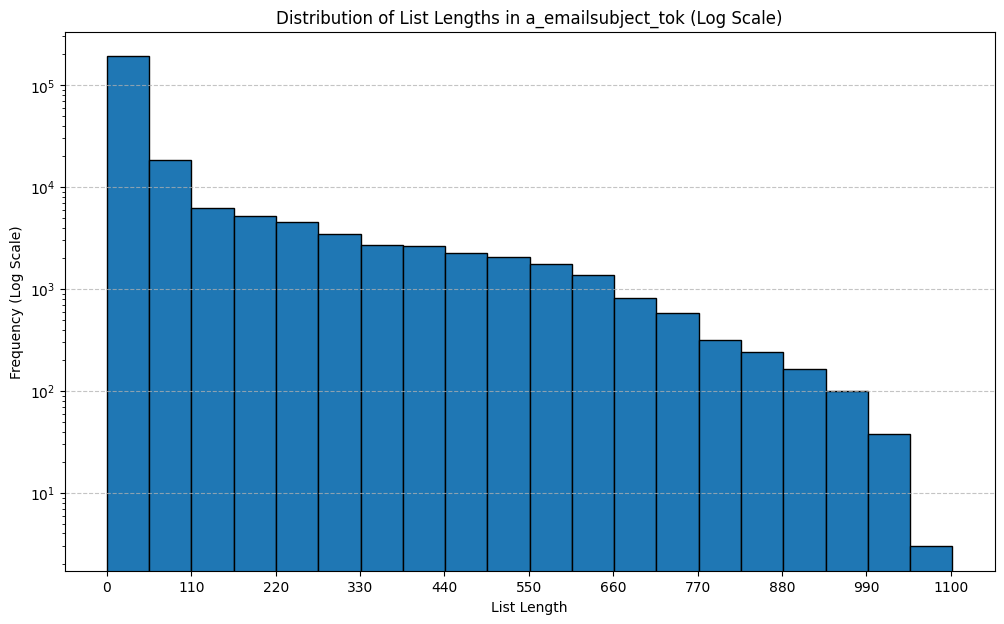

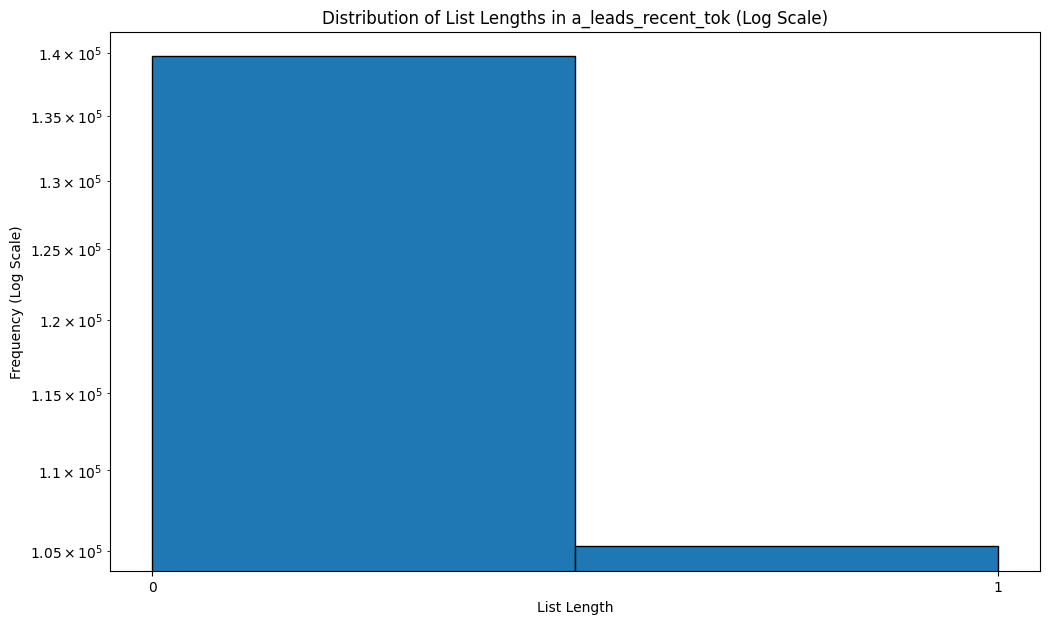

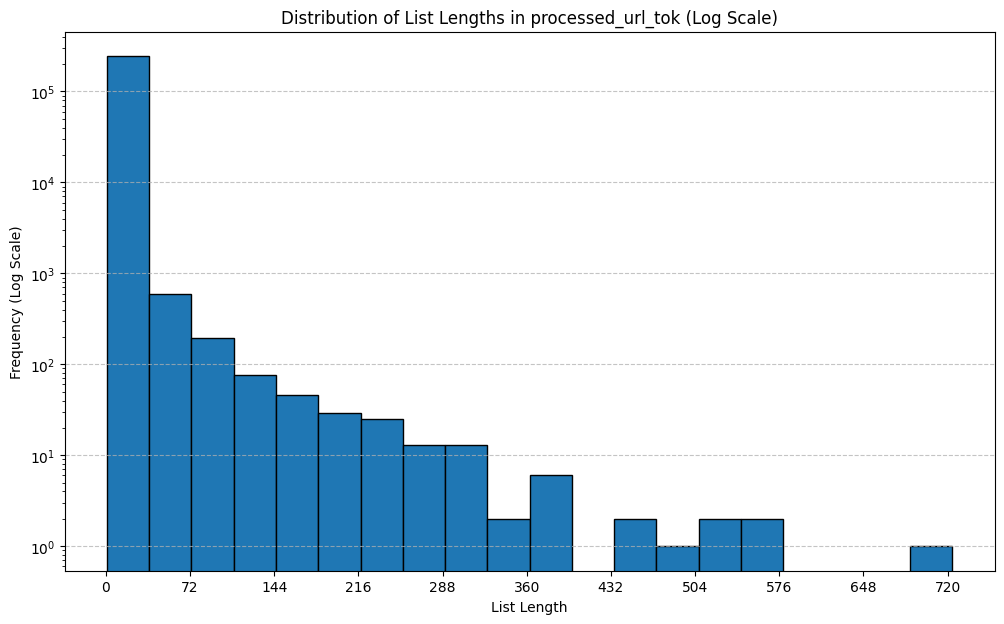

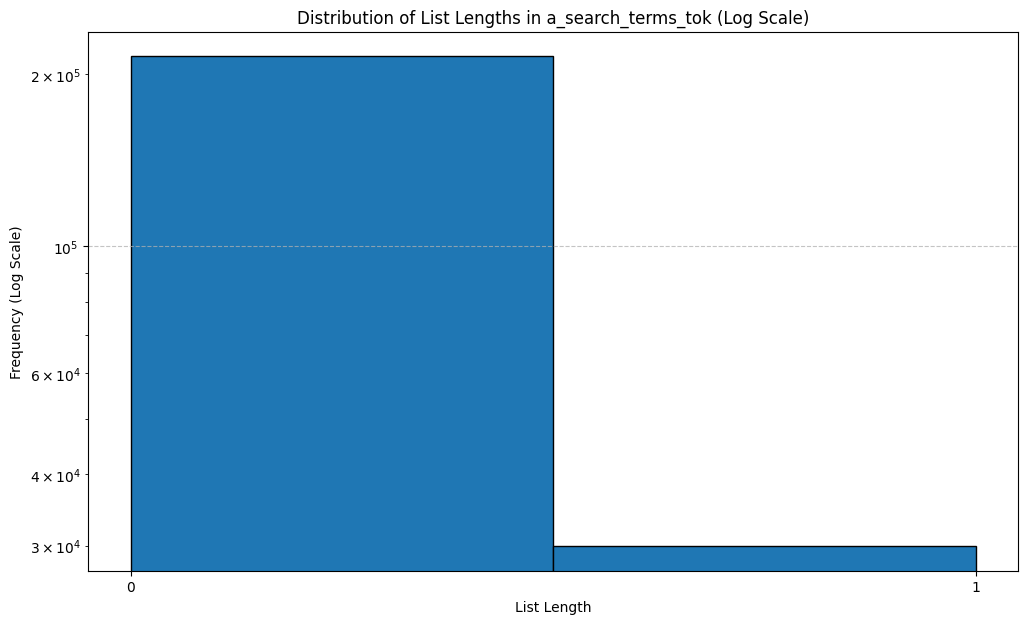

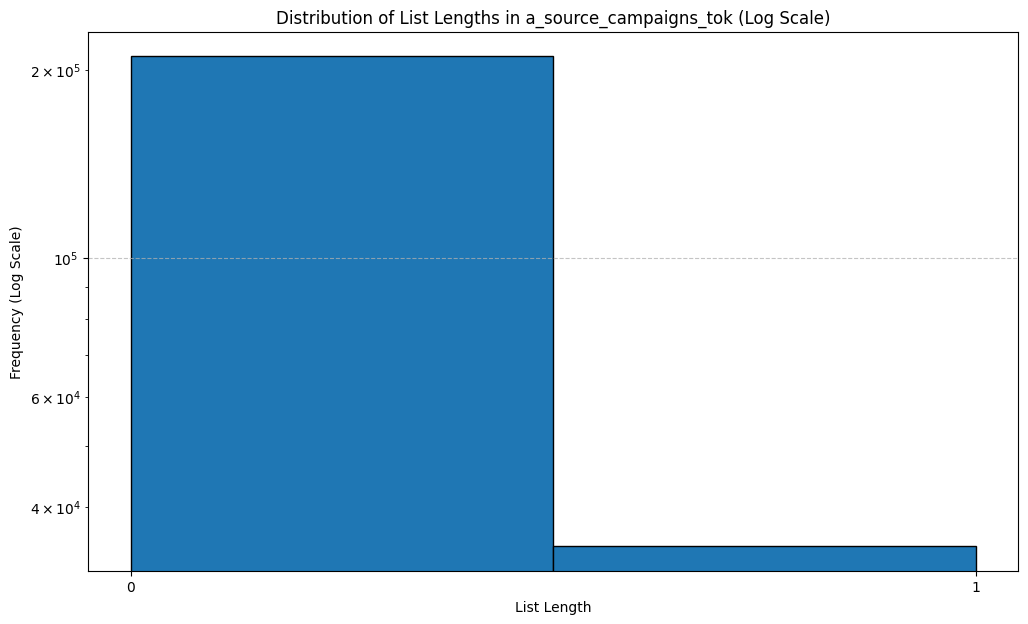

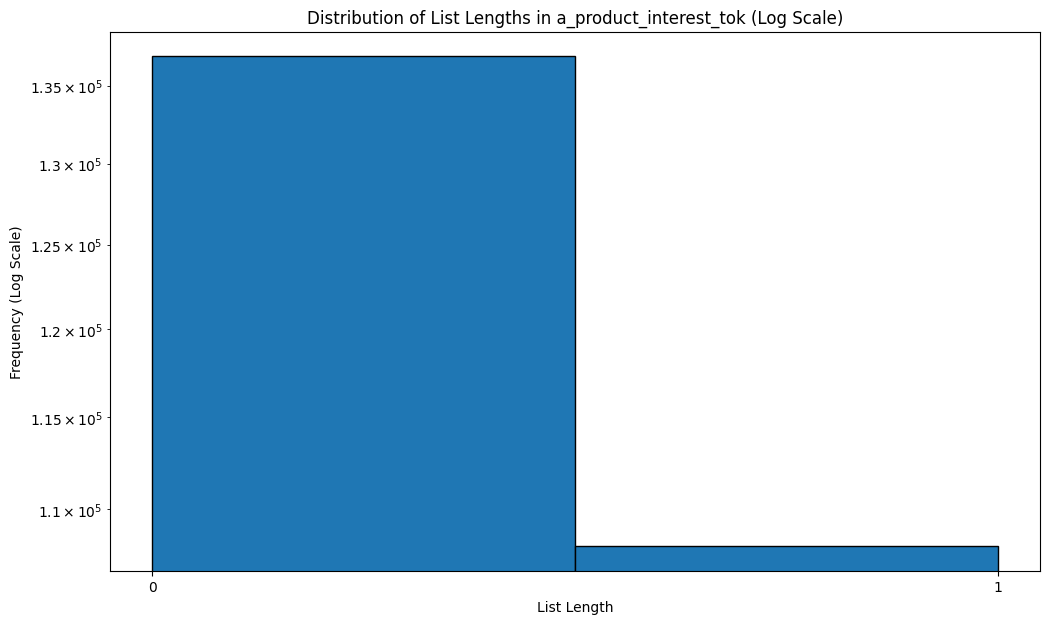

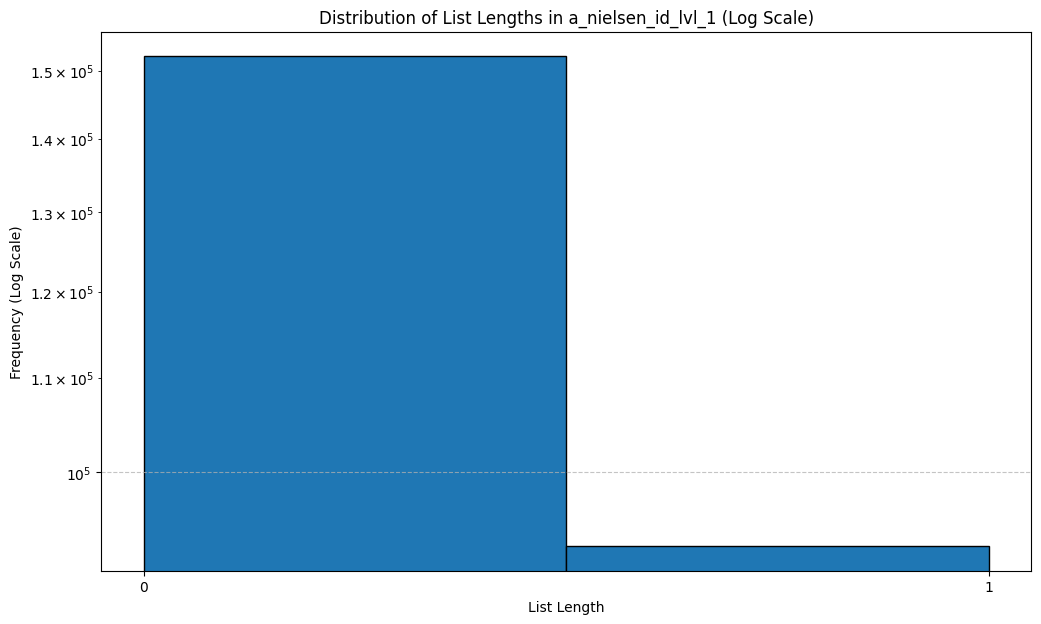

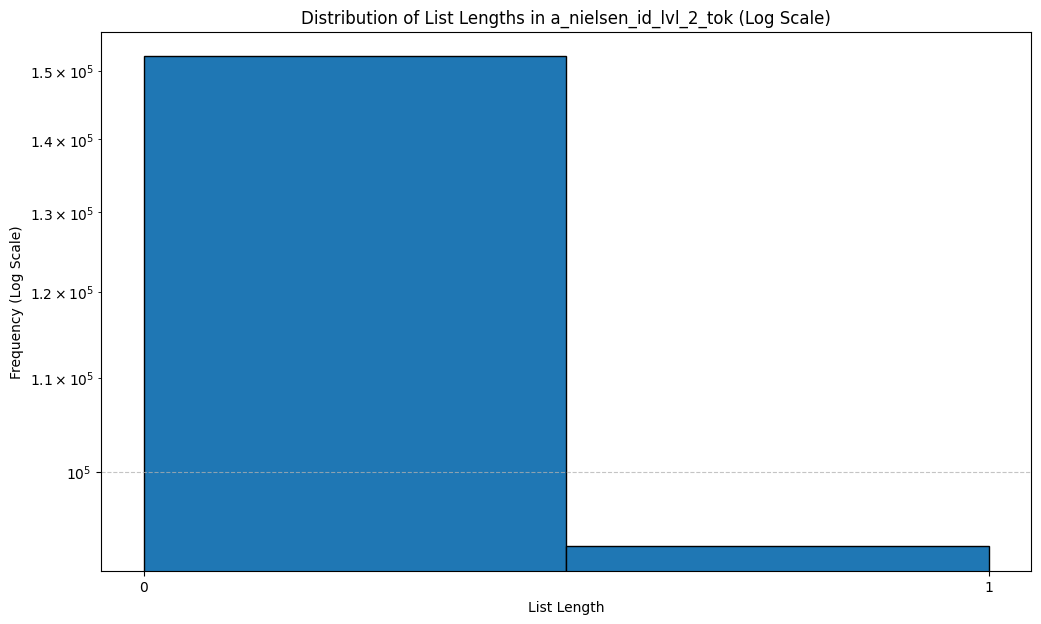

In [14]:


import matplotlib.pyplot as plt
list_lengths = encoded['a_emailsubject_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_emailsubject_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()

list_lengths = encoded['a_leads_recent_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_leads_recent_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()


list_lengths = encoded['processed_url_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in processed_url_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()


list_lengths = encoded['a_search_terms_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_search_terms_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()



list_lengths = encoded['a_source_campaigns_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_source_campaigns_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()


list_lengths = encoded['a_product_interest_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_product_interest_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()




#-------------------------------------------------------


list_lengths = encoded['a_nielsen_id_lvl_1_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)a_product_interest":40,"a_currency"
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_nielsen_id_lvl_1 (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()



list_lengths = encoded['a_nielsen_id_lvl_2_tok'].apply(len)

# Create a histogram with a fixed number of bins and a logarithmic y-axis
plt.figure(figsize=(12, 7))

# Determine optimal number of bins (e.g., using Freedman-Diaconis rule or a simpler fixed number)a_product_interest":40,"a_currency"
# For simplicity and general readability, let's start with 20 bins, or fewer if the max length is small.
max_len = list_lengths.max()
num_bins = min(20, max_len + 1) # Ensure at least one bin per length up to num_bins

plt.hist(list_lengths, bins=num_bins, edgecolor='black', log=True)
plt.title('Distribution of List Lengths in a_nielsen_id_lvl_2_tok (Log Scale)')
plt.xlabel('List Length')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(np.arange(0, max_len + 1, max(1, max_len // 10))) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.show()

In [ ]:
#assert df_train['is_won_status'].apply(lambda x:  isinstance(x, object) and len(x)).all()
#invalid_rows = df_train[~df_train['is_won_status'].apply(lambda x: isinstance(x, object) and len(x) == 1)]
#print(invalid_rows)

In [15]:
invalid_rows_type = df_train[~df_train['is_won_status'].apply(lambda x: isinstance(x, bool))]

if not invalid_rows_type.empty:
    print(f"Found {len(invalid_rows_type)} rows where 'is_won_status' is not a boolean type:")
    display(invalid_rows_type.head())
else:
    print("All values in 'is_won_status' column are valid boolean types.")

All values in 'is_won_status' column are valid boolean types.


In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, 1, bias=False)   # learns importance per token

    def forward(self, x):
        # x: (B, T, D)
        scores = self.W(x)                       # (B, T, 1)
        weights = F.softmax(scores, dim=1)       # (B, T, 1)
        pooled = torch.sum(weights * x, dim=1)   # (B, D)
        return pooled

# ---------------------------------------------------------
# Residual MLP block
# ---------------------------------------------------------
class ResidualMLP(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.act = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.act(self.bn1(self.fc1(x)))
        out = self.bn2(self.fc2(out))
        return self.act(out + residual)


class ResidualMLPStack(nn.Module):
    def __init__(self, dim, hidden, num_blocks=4):
        super().__init__()
        self.blocks = nn.Sequential(*[ResidualMLP(dim, hidden) for _ in range(num_blocks)])

    def forward(self, x):
        return self.blocks(x)


# ---------------------------------------------------------
# Bilinear Residual MLP block
# ---------------------------------------------------------
class BilinearResidualMLP(nn.Module):
    def __init__(self, dim, hidden, dropout=0.0, norm="layer"):
        super().__init__()
        Norm = nn.LayerNorm if norm == "layer" else nn.BatchNorm1d

        self.u = nn.Linear(dim, hidden, bias=False)
        self.v = nn.Linear(dim, hidden, bias=False)
        self.proj = nn.Linear(hidden, dim)

        self.norm = Norm(dim)
        self.act = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        nn.init.zeros_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x):
        # second-order feature interactions in hidden space
        h = self.u(x) * self.v(x)          # elementwise product
        h = self.drop(self.act(h))
        upd = self.norm(self.proj(h))
        return self.act(x + upd)


# ---------------------------------------------------------
# Residual MLP projection block
# ---------------------------------------------------------
class ResidualMLPProj(nn.Module):
    def __init__(self, dim_in, dim_out, hidden):
        super().__init__()
        self.fc1 = nn.Linear(dim_in, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, dim_out)
        self.bn2 = nn.BatchNorm1d(dim_out)
        self.act = nn.ReLU()

        self.proj = nn.Identity() if dim_in == dim_out else nn.Linear(dim_in, dim_out)

    def forward(self, x):
        residual = self.proj(x)
        out = self.act(self.bn1(self.fc1(x)))
        out = self.bn2(self.fc2(out))
        return self.act(out + residual)

class MultiEmbeddingModel(nn.Module):
    def __init__(self, vocab_sizes, emb_dim=256,emb_dims=[],  hidden=1024):
        """
        vocab_sizes: list of vocab sizes for each embedding
        emb_dim: embedding dimension for all embeddings
        """
        super().__init__()

        self.emb_dim_total = 0
        for embd in emb_dims:
            self.emb_dim_total += embd

        self.emb_layers = nn.ModuleList([
            #nn.Embedding(vocab, emb_dim) for vocab in vocab_sizes
            nn.Embedding(vocab, embd) for vocab,embd in zip(vocab_sizes,emb_dims)
        ])

        self.pool_layers = nn.ModuleList([
            #AttentionPooling(emb_dim) for _ in vocab_sizes
            AttentionPooling(e) for e in emb_dims
        ])

        self.project_pool = nn.ModuleList([
            nn.Sequential(
              nn.Linear(e,int(e//4)),
              #nn.Linear(emb_dim,int(emb_dim//4)),
              nn.ReLU()
            )
            for e in emb_dims# _ in vocab_sizes
        ])

        self.gates = nn.ModuleList([
            nn.Sequential(
                nn.Linear(int(e//4), 1),
                #nn.Linear(int(emb_dim//4), 1),
                nn.Sigmoid() # Gate value in [0, 1]
            )
            for e in emb_dims#_ in vocab_sizes
        ])

        # After pooling each embedding → we get N vectors of size emb_dim
        #total_dim = len(vocab_sizes) * int(emb_dim//1)
        #total_dim = len(vocab_sizes) * int(emb_dim//1)

        # Residual MLP on concatenated pooled embeddings
        #self.mlp = ResidualMLP(total_dim, hidden)
        #self.mlp = ResidualMLP(self.emb_dim_total, hidden)
        self.mlp = ResidualMLPStack(self.emb_dim_total, hidden,num_blocks=6)


        self.float_proj = nn.Sequential(
            nn.Linear(1 + 3, 64), # revenue + catboost
            #nn.Linear(1 , 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU()
        )
        # Final classifier
        self.classifier = nn.Linear(self.emb_dim_total+256, 1)
        #self.classifier = nn.Linear(total_dim+256, 1)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, *inputs,page_views,avg_sess,last_order,last_vist):#,days_open):
        """
        inputs: list of tensors
            each tensor is (B, Ti) where Ti is the sequence length for that embedding
        """

        pooled_outputs = []

        #for x, emb, pool in zip(inputs, self.emb_layers, self.pool_layers):
        for x, emb in zip(inputs, self.emb_layers):
            e = emb(x)          # (B, Ti, D)
            #p = pool(e)         # (B, D)
            p = torch.max(e, dim=1).values#torch.max(e, dim=1).values
            #p = self.pool(e).squeeze(-1)
            #p = torch.mean(e, dim=1)#.values
            pooled_outputs.append(p)



        h = torch.cat(pooled_outputs, dim=1)   # (B, N*D)

        # Residual MLP
        h = self.mlp(h)
        float_feats = self.float_proj(torch.cat([page_views,avg_sess,last_order,last_vist], dim=1)) # (B, 16) , days_open
        #float_feats = self.float_proj(page_views)
        combined = torch.cat([h, float_feats], dim=1)
        out = self.classifier(combined)
        # Classifier
        #out = self.classifier(h)               # (B, 1)
        return out



In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

class MultiSourceDatasetWithFloatCatagorical(Dataset):
    def __init__(self, df, max_lens=(630, 10, 10, 1, 20, 200, 10, 10), catboost_cols=None):
        self.df = df
        self.max_lens = max_lens
        self.catboost_cols = catboost_cols or ['a_currency_cb']

    def pad_or_truncate(self, tokens, max_len):
        tokens = tokens[:max_len]
        return tokens + [0] * (max_len - len(tokens))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        email = self.pad_or_truncate(row['a_emailsubject_tok'], self.max_lens[0])
        leads = self.pad_or_truncate(row['a_leads_recent_tok'], self.max_lens[1])
        search_terms = self.pad_or_truncate(row['a_search_terms_tok'], self.max_lens[2])
        campaign = self.pad_or_truncate(row['a_source_campaigns_tok'], self.max_lens[3])
        product = self.pad_or_truncate(row['a_product_interest_tok'], self.max_lens[4])
        url = self.pad_or_truncate(row['processed_url_tok'], self.max_lens[5])
        n1 = self.pad_or_truncate(row['a_nielsen_id_lvl_1_tok'], self.max_lens[6])
        n2 = self.pad_or_truncate(row['a_nielsen_id_lvl_2_tok'], self.max_lens[7])

        page_views = torch.tensor([row['page_views']], dtype=torch.float32)
        avg_sess = torch.tensor([row['avg_session_duration']], dtype=torch.float32)
        last_order = torch.tensor([row['days_since_last_order']], dtype=torch.float32)
        last_vist = torch.tensor([row['days_since_last_visit']], dtype=torch.float32)
        iid = torch.tensor([row['Individual_id']], dtype=torch.long)

        # Fix: Handle NAType/NaN values for is_won_status in the test set
        won_val = row['is_won_status']
        if pd.isna(won_val):
            won_val = 0.0
        won = torch.tensor(float(won_val), dtype=torch.float32).unsqueeze(0)

        email_id = row['std_email_address']

        return {
            'email': torch.tensor(email, dtype=torch.long),
            'leads': torch.tensor(leads, dtype=torch.long),
            'search_terms': torch.tensor(search_terms, dtype=torch.long),
            'campaign': torch.tensor(campaign, dtype=torch.long),
            'product': torch.tensor(product, dtype=torch.long),
            'url': torch.tensor(url, dtype=torch.long),
            'n1': torch.tensor(n1, dtype=torch.long),
            'n2': torch.tensor(n2, dtype=torch.long),
            'page_views': page_views,
            'avg_sess': avg_sess,
            'last_order': last_order,
            'last_vist': last_vist,
            'iid': iid,
            'won': won,
            'email_id': email_id
        }

    def __len__(self):
        return len(self.df)

In [19]:
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
print(device)
#enc = MultiColumnStringTokenEncoder(
#    {"processed_url":20000,"a_source_campaigns": 3000, "a_leads_recent": 30, "a_search_terms":60000,"a_emailsubject":2000,\
#     "a_product_interest":60,"a_nielsen_id_lvl_1":5,"a_nielsen_id_lvl_2":10}
#)
#enc = MultiColumnStringTokenEncoder(
#    {"processed_url":2000,"a_source_campaigns": 3000, "a_leads_recent": 30, "a_search_terms":6000,"a_emailsubject":2000,\
#     "a_product_interest":60,"a_nielsen_id_lvl_1":5,"a_nielsen_id_lvl_2":10}, # max 3 tokens per column
# {"processed_url":40000,"a_source_campaigns": 3000, "a_leads_recent": 30, "a_search_terms":120000,"a_emailsubject":2000,\
#"a_product_interest":60,"a_nielsen_id_lvl_1":5,"a_nielsen_id_lvl_2":10}, emb_dims = [1024,64,4196,512,64,2048,32,32]
model = MultiEmbeddingModel(vocab_sizes=(2001, 31, 6001, 3001, 61, 2001,6,11), emb_dim=2048,emb_dims = [512,256,4096,256,256,2048,64,64])
#model = MultiEmbeddingModel(vocab_sizes=(2001, 31, 56001, 3001, 61, 38001,6,11), emb_dim=2048)
model = model.to(device)


#in training #
dataset = MultiSourceDatasetWithFloatCatagorical(df_train, catboost_cols=1)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)
EMBED_KEYS = ('email', 'leads', 'search_terms', 'campaign', 'product', 'url','n1','n2')#'currency',

def train_model(model, dataloader, epochs=30, lr=1e-3):
    model.train()
    #optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()


    #torch.autograd.set_detect_anomaly(True)
    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
          optimizer.zero_grad()

          inputs = tuple(batch[k] for k in EMBED_KEYS)


          inputs = tuple(x.to(device, non_blocking=True) for x in inputs)
          won = batch['won'].to(device)                     # (B, 1)
          page_views = batch['page_views'].to(device)       # (B, 1)
          avg_sess = batch['avg_sess'].to(device)
          last_order = batch['last_order'].to(device)
          last_vist = batch['last_vist'].to(device)



          #days_open  = batch['days_open'].to(device)        # (B, 1)

          preds = model(*inputs, page_views=page_views, avg_sess=avg_sess,
                        last_order=last_order, last_vist=last_vist)#, days_open=days_open)
          loss = criterion(preds, batch['won'].to(device))
          loss.backward()
          optimizer.step()
          total_loss += loss.item()

        print(f"Epoch {epoch+1}: Loss = {total_loss / len(dataloader):.4f}")



train_model(model, dataloader, epochs=35, lr=1e-3)

cuda
Epoch 1: Loss = 0.8186
Epoch 2: Loss = 0.7180
Epoch 3: Loss = 0.6642
Epoch 4: Loss = 0.6375
Epoch 5: Loss = 0.6171
Epoch 6: Loss = 0.6020
Epoch 7: Loss = 0.5847
Epoch 8: Loss = 0.5688
Epoch 9: Loss = 0.5574
Epoch 10: Loss = 0.5399
Epoch 11: Loss = 0.5229
Epoch 12: Loss = 0.5103
Epoch 13: Loss = 0.4959
Epoch 14: Loss = 0.4820
Epoch 15: Loss = 0.4788
Epoch 16: Loss = 0.4636
Epoch 17: Loss = 0.4505
Epoch 18: Loss = 0.4480
Epoch 19: Loss = 0.4434
Epoch 20: Loss = 0.4308
Epoch 21: Loss = 0.4190
Epoch 22: Loss = 0.4146
Epoch 23: Loss = 0.4111
Epoch 24: Loss = 0.4439
Epoch 25: Loss = 0.4024
Epoch 26: Loss = 0.4013
Epoch 27: Loss = 0.3884
Epoch 28: Loss = 0.3956
Epoch 29: Loss = 0.3809
Epoch 30: Loss = 0.3749
Epoch 31: Loss = 0.3830
Epoch 32: Loss = 0.3869
Epoch 33: Loss = 0.3615
Epoch 34: Loss = 0.3633
Epoch 35: Loss = 0.3583


In [ ]:

batch_size = 2048# 8092#int(2.5*8096)# + 8096
device = "cpu"
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
model.to(device)
model.eval()


MultiEmbeddingModel(
  (emb_layers): ModuleList(
    (0): Embedding(2001, 512)
    (1): Embedding(31, 256)
    (2): Embedding(60001, 4096)
    (3): Embedding(3001, 256)
    (4): Embedding(61, 256)
    (5): Embedding(20001, 2048)
    (6): Embedding(6, 64)
    (7): Embedding(11, 64)
  )
  (pool_layers): ModuleList(
    (0): AttentionPooling(
      (W): Linear(in_features=512, out_features=1, bias=False)
    )
    (1): AttentionPooling(
      (W): Linear(in_features=256, out_features=1, bias=False)
    )
    (2): AttentionPooling(
      (W): Linear(in_features=4096, out_features=1, bias=False)
    )
    (3-4): 2 x AttentionPooling(
      (W): Linear(in_features=256, out_features=1, bias=False)
    )
    (5): AttentionPooling(
      (W): Linear(in_features=2048, out_features=1, bias=False)
    )
    (6-7): 2 x AttentionPooling(
      (W): Linear(in_features=64, out_features=1, bias=False)
    )
  )
  (project_pool): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=512, out_fe

In [ ]:
err = 0
number_correct_convert = 0
number_total_total = 0
number_missed_convert = 0
number_bad_convert = 0
missed_convert = []
bad_convert_pred = []

#EMBED_KEYS = ('email', 'leads', 'search_terms', 'campaign', 'product', 'url')
EMBED_KEYS = ('email', 'leads', 'search_terms', 'campaign', 'product', 'url','n1','n2')#
with open("results_04_9_0.txt", "w") as f:
  with torch.no_grad():
    for batch in loader:


        inputs = tuple(batch[k] for k in EMBED_KEYS)
        inputs = tuple(x.to(device, non_blocking=True) for x in inputs)

        won = batch['won'].to(device)                     # (B, 1)
        page_views = batch['page_views'].to(device)       # (B, 1)
        avg_sess = batch['avg_sess'].to(device)
        last_order = batch['last_order'].to(device)
        last_vist = batch['last_vist'].to(device)




        preds = model(*inputs, page_views=page_views, avg_sess=avg_sess,
                      last_order=last_order, last_vist=last_vist)#, days_open=days_open)



        for p,l in zip(torch.sigmoid(preds),batch['won'].to(device)):



          pp = float(p.squeeze().cpu().item())
          ll = float(l.squeeze().cpu().item())

          choice = pp >= 0.5


          f.write(f"Lead = {ll}, convert probability = {pp},  convert = {choice}\n")

          if choice == True and ll > 0.5:
            number_correct_convert = number_correct_convert + 1

          if ll > 0.5:
            number_total_total = number_total_total + 1

          if choice == True and  ll < 0.5:
            number_missed_convert = number_missed_convert + 1
            missed_convert.append(pp)

          if choice == False and  ll > 0.5:
            number_bad_convert = number_bad_convert + 1
            bad_convert_pred.append(pp)


          err = err + abs(float(choice) - ll)
        break
    print(err/batch_size)

print(f"number correct convert : {number_correct_convert}")
print(f"number total convert : {number_total_total}")
print('                              ')
print('                              ')
print(f"number false positives : {number_missed_convert}")
for mc in missed_convert:
  print(f"false positive val: {mc}")


print('                              ')
print('                              ')

print(f"false negatives : {number_bad_convert}")
for bc in bad_convert_pred:
  print(f"false negative val : {bc}")# ->30/2048 set the threshold to .7 then about 60% of the positives are predicted
                                     #  but 98.2% of the predictions are correct alomost perfect. the overall accuracy
                                     #  is still 80% +

0.154296875
number correct convert : 685
number total convert : 879
                              
                              
number false positives : 122
false positive val: 0.7129457592964172
false positive val: 0.6497299671173096
false positive val: 0.5020458102226257
false positive val: 0.552551805973053
false positive val: 0.5708082914352417
false positive val: 0.7583876848220825
false positive val: 0.611254096031189
false positive val: 0.8797643780708313
false positive val: 0.5080026388168335
false positive val: 0.5625272393226624
false positive val: 0.5052592754364014
false positive val: 0.5323565006256104
false positive val: 0.7059937715530396
false positive val: 0.7346667051315308
false positive val: 0.6382520794868469
false positive val: 0.5305602550506592
false positive val: 0.6911561489105225
false positive val: 0.6486591100692749
false positive val: 0.7286215424537659
false positive val: 0.6369946599006653
false positive val: 0.7056314945220947
false positive val: 0.51

In [ ]:
df_test['is_won_status'] = df_test['is_won_status'].apply(lambda x: pd.to_numeric(x, errors='coerce')).fillna(-1.0)

/tmp/ipykernel_2472/737183018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['is_won_status'] = df_test['is_won_status'].apply(lambda x: pd.to_numeric(x, errors='coerce')).fillna(-1.0)


In [ ]:
del df_train
import gc
gc.collect()

120

In [24]:
df_test.head(10)

Individual_id a_search_terms a_source_campaigns  \
2      100001264207             []                 []   
9      100000966872             []                 []   
10  888100003092594             []                 []   
15  888100002397180             []                 []   
16     100002941148        [91387]        [(organic)]   
48     100000168306             []                 []   
54  888100001951876             []                 []   
76     100001563712             []                 []   
77     100001417132             []                 []   
83  888100003152057             []                 []   

            a_product_interest a_leads_recent a_nielsen_id_lvl_1  \
2                           []             []                 []   
9                           []             []   [Pharma/Biotech]   
10                          []             []          [Dealers]   
15                          []             []                 []   
16                          []             []                 []   
48                          []             []            [Other]   
54                          []             []                 []   
76                          []             []                 []   
77                          []             []         [Academia]   
83  [Other (Specify in Notes)]     [Referral]                 []   

        a_nielsen_id_lvl_2  page_views  days_since_last_order  \
2                       []           0                   -1.0   
9         [Pharmaceutical]           0                 1043.0   
10   [Dealers/Exp./Resell]           0                  474.0   
15                      []           0                   -1.0   
16                      []          23                   -1.0   
48  [Miscellaneous unsegm]           0                  471.0   
54                      []           0                   -1.0   
76                      []           0                   -1.0   
77  [Universities/Schools]           0                 1056.0   
83                      []           0                   -1.0   

    days_since_last_visit  avg_session_duration  \
2                    -1.0                  -1.0   
9                    -1.0                  -1.0   
10                   -1.0                  -1.0   
15                   -1.0                  -1.0   
16                  624.0                 650.0   
48                   -1.0                  -1.0   
54                   -1.0                  -1.0   
76                   -1.0                  -1.0   
77                   -1.0                  -1.0   
83                   -1.0                  -1.0   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         a_url  \
2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           []   
9                                  

In [30]:

import torch
from torch.utils.data import Dataset, DataLoader

def custom_collate_fn(batch_list):
    # This collate_fn is designed to handle the specific dictionary structure
    # returned by MultiSourceDatasetWithFloatCatagorical.

    # First, separate the email_ids, which are strings
    email_ids = [item['email_id'] for item in batch_list]

    # Handle Individual_ids separately as well to ensure they stay as a list or specific tensor type
    individual_ids = [item['iid'].item() for item in batch_list]

    # Then, handle all other items (which are expected to be tensors) by stacking them
    batched_tensors = {}
    for key in batch_list[0].keys():
        if key not in ['email_id', 'iid']:
            batched_tensors[key] = torch.stack([item[key] for item in batch_list])

    # Add the collected IDs back to the dictionary
    batched_tensors['email_id'] = email_ids
    batched_tensors['Individual_id'] = individual_ids

    return batched_tensors


dataset = MultiSourceDatasetWithFloatCatagorical(df_test, catboost_cols=1)
# Fixed: Uncommented collate_fn to ensure 'Individual_id' is included in the batch
dataloader = DataLoader(dataset, batch_size=256, shuffle=False, collate_fn=custom_collate_fn)

err = 0
number_correct_convert = 0
number_total_total = 0
number_missed_convert = 0
number_bad_convert = 0
missed_convert = []
bad_convert_pred = []
EMBED_KEYS = ('email', 'leads', 'search_terms', 'campaign', 'product', 'url','n1','n2')

all_email_ids = []
all_predictions = []

with torch.no_grad():
    for batch in dataloader:
        inputs = tuple(batch[k] for k in EMBED_KEYS)

        inputs = tuple(x.to(device, non_blocking=True) for x in inputs)
        page_views = batch['page_views'].to(device)       # (B, 1)
        avg_sess = batch['avg_sess'].to(device)
        last_order = batch['last_order'].to(device)
        last_vist = batch['last_vist'].to(device)

        preds = model(*inputs, page_views=page_views, avg_sess=avg_sess,
                      last_order=last_order, last_vist=last_vist)

        # Now batch['Individual_id'] will exist thanks to the custom_collate_fn
        for iid, p in zip(batch['Individual_id'], torch.sigmoid(preds)):
            all_email_ids.append(iid)
            all_predictions.append(p.squeeze().cpu().item())


print('done')


done


In [31]:
import pandas as pd

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'Individual_id': all_email_ids,
    'confidence': all_predictions
})

# Save to CSV for persistent storage/upload
results_df.to_csv('iid_predictions_may.csv', index=False)

print(f"Created DataFrame with {len(results_df)} predictions.")
display(results_df.head())

Created DataFrame with 100000 predictions.


,Individual_id,confidence
0,100001264207,0.348203
1,100000966872,0.768415
2,888100003092594,0.659339
3,888100002397180,0.426823
4,100002941148,0.032859


In [32]:
from google.cloud import bigquery

# Initialize BigQuery client
client = bigquery.Client(project="expanded-nebula-754")

# BigQuery destination table
table_id = "expanded-nebula-754.sandbox_crdow.Leads_iid_Predictions"

# Configure the load job
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,
    autodetect=True,
    write_disposition="WRITE_TRUNCATE"
)

# Load the CSV into BigQuery
with open("iid_predictions_may.csv", "rb") as source_file:
    load_job = client.load_table_from_file(
        source_file,
        table_id,
        job_config=job_config
    )

# Wait for completion
load_job.result()

table = client.get_table(table_id)
print(f"Successfully loaded {table.num_rows} rows into {table_id}.")

Successfully loaded 100000 rows into expanded-nebula-754.sandbox_crdow.Leads_iid_Predictions.


In [ ]:
from google.cloud import bigquery

# Initialize client
client = bigquery.Client(project="expanded-nebula-754")

# Path to your CSV file
file_path = "/content/predictions_old.csv"

# BigQuery destination table
table_id = "expanded-nebula-754.sandbox_crdow.Leads_Predictions_old"

# Configure the load job
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,        # Assuming the CSV has a header row
    autodetect=True,            # Let BigQuery infer schema
    write_disposition="WRITE_TRUNCATE"  # Overwrite table
)

# Load the CSV
with open(file_path, "rb") as source_file:
    load_job = client.load_table_from_file(
        source_file,
        table_id,
        job_config=job_config
    )

# Wait for completion
load_job.result()

# Print results
table = client.get_table(table_id)
print(f"Loaded {table.num_rows} rows into {table_id}.")

Loaded 3036208 rows into expanded-nebula-754.sandbox_crdow.Leads_Predictions_old.
